## Import Libraries

In [20]:
import mujoco
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os, json, imageio, base64
from scipy.spatial.transform import Rotation
from IPython.display import display, HTML
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


XML_PATH     = "/Users/kchong99/Documents/Master/ME 569/owsbr/Ozzy/segway_2.xml"
SAVE_DIR     = "SavedSeeds"

TRAIN_SEEDS  = [42]
VERIFY_SEEDS = [788, 999, 555, 321, 444]
os.makedirs(SAVE_DIR, exist_ok=True)

## Segway starts from the ground

In [21]:
def get_ground_contact_z(xml_path, tilt=0.0):
    """
    Find the correct z so the segway sits ON the ground
    at the given tilt — not floating, not underground.
    """
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)

    # set tilt at high z, drop freely with no control
    mujoco.mj_resetData(model, data)
    rot  = Rotation.from_euler('y', tilt)
    quat = rot.as_quat()
    data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]
    data.qpos[2]   = 2.0   # start well above ground
    data.qvel[:]   = 0.0
    mujoco.mj_forward(model, data)

    # drop until it settles — no control, gravity only
    for _ in range(2000):
        data.ctrl[:] = 0.0
        mujoco.mj_step(model, data)
        # settled when vertical velocity near zero and low height
        if abs(data.qvel[2]) < 0.001 and data.qpos[2] < 0.5:
            break

    return data.qpos[2]


# find ground z for different tilts
print("Ground contact heights:")
for tilt in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    z = get_ground_contact_z(XML_PATH, tilt)
    print(f"  tilt={tilt:.1f} rad "
          f"({np.degrees(tilt):.1f}°) → z={z:.4f}")
    
    
# run once at startup — build lookup table
print("Building ground contact lookup table...")
GROUND_Z_TABLE = {}
for tilt in np.arange(0.0, 1.1, 0.05):
    GROUND_Z_TABLE[round(tilt, 2)] = \
        get_ground_contact_z(XML_PATH, tilt)
    GROUND_Z_TABLE[round(-tilt, 2)] = \
        GROUND_Z_TABLE[round(tilt, 2)]  # symmetric
print("Done.")
print(GROUND_Z_TABLE)


def get_z_for_tilt(tilt):
    """Look up nearest precomputed z for given tilt."""
    key = round(round(abs(tilt) / 0.05) * 0.05, 2)
    key = min(key, 1.0)
    return GROUND_Z_TABLE.get(key, GROUND_Z_TABLE[0.0])


Ground contact heights:
  tilt=0.0 rad (0.0°) → z=-0.4269
  tilt=0.1 rad (5.7°) → z=-0.4352
  tilt=0.2 rad (11.5°) → z=-0.4333
  tilt=0.3 rad (17.2°) → z=-0.4260
  tilt=0.4 rad (22.9°) → z=-0.4260
  tilt=0.5 rad (28.6°) → z=-0.4860
Building ground contact lookup table...
Done.
{np.float64(0.0): np.float64(-0.4269457976866716), np.float64(0.05): np.float64(-0.42600965277743413), np.float64(-0.05): np.float64(-0.42600965277743413), np.float64(0.1): np.float64(-0.43517228079836734), np.float64(-0.1): np.float64(-0.43517228079836734), np.float64(0.15): np.float64(-0.4260074754450069), np.float64(-0.15): np.float64(-0.4260074754450069), np.float64(0.2): np.float64(-0.43330925457474345), np.float64(-0.2): np.float64(-0.43330925457474345), np.float64(0.25): np.float64(-0.42600562200700537), np.float64(-0.25): np.float64(-0.42600562200700537), np.float64(0.3): np.float64(-0.4260051652945965), np.float64(-0.3): np.float64(-0.4260051652945965), np.float64(0.35): np.float64(-0.42600525771813064),

## Other functions

In [22]:
def get_obs(data):
    quat  = data.qpos[3:7]
    rot   = Rotation.from_quat(
        [quat[1], quat[2], quat[3], quat[0]])
    theta = rot.as_euler('xyz')[1]
    return np.array([data.qpos[0], data.qvel[0],
                     theta, data.qvel[4]],
                    dtype=np.float32)


def normalize_obs(obs):
    x, x_dot, theta, theta_dot = obs
    return np.array([
        np.clip(x         / 2.4,  -1, 1),
        np.clip(x_dot     / 5.0,  -1, 1),
        np.clip(theta     / 1.57, -1, 1),
        np.clip(theta_dot / 5.0,  -1, 1),
    ], dtype=np.float32)

## PPO and reward function

In [23]:
class NavPPO(nn.Module):
    def __init__(self, torque_max=5.0):
        super().__init__()
        self.torque_max = torque_max
        self.net = nn.Sequential(
            nn.Linear(5, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(128, 1)
        self.actor_log_std = nn.Parameter(
            torch.tensor([-0.5]))   # std≈0.6
        self.critic        = nn.Linear(128, 1)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, 0.5)
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(
            self.actor_mean.weight, 0.01)

    def forward(self, x):
        s = self.net(x)
        return self.actor_mean(s), self.critic(s)

    def get_action(self, obs, goal_x,
                   deterministic=False):
        dist_norm = float(np.clip(
            (goal_x - obs[0]) / 5., -1, 1))
        inp = np.array([
            *normalize_obs(obs), dist_norm],
            dtype=np.float32)
        t         = torch.FloatTensor(inp)
        mean, val = self(t)
        std       = self.actor_log_std.exp()\
                        .clamp(0.1, 2.0)
        dist      = torch.distributions.Normal(
            mean, std)
        raw       = mean if deterministic \
                    else dist.rsample()
        logp      = dist.log_prob(raw).sum(-1)
        torque    = torch.tanh(raw) * self.torque_max
        return torque.item(), logp, val


def nav_reward(obs, prev_x, goal_x, at_goal, done, step):
    x, x_dot, theta, theta_dot = obs

    if done:    return -20.0
    if at_goal: return 50.0

    prev_dist = abs(prev_x - goal_x)
    curr_dist = abs(x - goal_x)

    # progress (same as before)
    r = (prev_dist - curr_dist) * 15.0

    # continuous pull — penalise being far from goal
    r -= curr_dist * 0.05
    
    r += 0.02  # ~+60 over a 3000-step episode for staying up

    # stability
    if abs(theta) > 0.20:
        r -= (abs(theta) - 0.2) * 5.0

    return float(r)

## Train PPO (Single)

In [24]:
def train_nav(x_start=0.0, x_goal=2.0,
              seed=42, tag="nav_v4",
              max_episodes=8000):
    torch.manual_seed(seed)
    np.random.seed(seed)

    net       = NavPPO(torque_max=5.0)
    optimizer = optim.Adam(
        net.parameters(), lr=3e-4, eps=1e-5)

    STEPS        = 2048
    EPOCHS       = 10
    CLIP         = 0.2
    GAMMA        = 0.99
    LAM          = 0.95
    MB           = 256
    ENT_START    = 0.01
    ENT_END   = 0.002
    ENT_DECAY = 3000   # episodes
    MAX_EP_STEPS = 3000
    
    

    rewards      = []
    losses       = []
    best_avg     = -9999
    best_weights = None

    def gae(rews, vals, dones, nv):
        adv, g = [], 0
        for r, v, d in zip(
                reversed(rews),
                reversed(vals),
                reversed(dones)):
            delta = r + GAMMA*nv*(1-d) - v
            g     = delta + GAMMA*LAM*(1-d)*g
            adv.insert(0, g); nv = v
        return adv

    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)
    dt    = model.opt.timestep

    def reset_env():
        mujoco.mj_resetData(model, data)
        data.qpos[0]   = x_start
        data.qpos[1]   = 0.0
        data.qpos[2]   = get_z_for_tilt(0.0)
        data.qpos[3:7] = [1, 0, 0, 0]
        data.qvel[:]   = 0.0
        data.qvel[4]   = np.random.uniform(
            -0.01, 0.01)
        mujoco.mj_forward(model, data)
        return get_obs(data)

    def env_step(torque):
        u            = float(np.clip(torque,-5.,5.))
        data.ctrl[0] = -u    # ← sign from verify_signs
        data.ctrl[1] = 0.0
        mujoco.mj_step(model, data)
        obs            = get_obs(data)
        x, _, theta, _ = obs
        done    = (abs(x)     > 2.8 or
                   abs(theta) > 0.5)
        at_goal = (abs(x - x_goal) < 0.10 and
                   abs(theta) < 0.25)   # ← must be upright at B
        return obs, done, at_goal

    obs          = reset_env()
    ep_total     = 0.0
    prev_x       = obs[0]
    ep_count     = 0
    arrivals     = 0
    from collections import deque
    recent_arrivals = deque(maxlen=200)
    rollout      = 0
    ep_step      = 0

    print(f"\nPure PPO Navigation | "
          f"A={x_start}m → B={x_goal}m")
    print(f"  No PID — PPO controls torque directly")
    print(f"  torque ∈ [-5, +5] Nm\n")
    
    print(f"{'Roll':>6} | {'Ep':>5} | "
        f"{'Avg':>8} | {'Rec%':>6} | "
        f"{'Loss':>8} | {'std':>5}")
    print("-" * 50)

    ENT = ENT_START
    while ep_count < max_episodes:
        ol,al,rl,vl,ll,dl = [],[],[],[],[],[]
        ep_rewards = []

        for _ in range(STEPS):
            with torch.no_grad():
                torque, logp, value = \
                    net.get_action(obs, x_goal, deterministic=False)

            ep_step += 1
            obs2, done, at_goal = env_step(torque)

            r = nav_reward(
                obs2, prev_x, x_goal,
                at_goal, done, ep_step)

            ep_total += r
            prev_x    = obs2[0]

            inp = np.array([
                *normalize_obs(obs),
                np.clip(
                    (x_goal-obs[0])/5.,-1,1)],
                dtype=np.float32)

            ol.append(inp)
            al.append([torque])
            rl.append(r)
            vl.append(value.item())
            ll.append(logp.item())
            dl.append(float(done or at_goal))

            obs = obs2

            timeout = (ep_step >= MAX_EP_STEPS)
            if done or at_goal or timeout:
                if at_goal:
                    arrivals += 1
                recent_arrivals.append(1 if at_goal else 0)
                if timeout and not at_goal:
                    rl[-1] -= 5.0
                ep_rewards.append(ep_total)
                ep_total  = 0.0
                ep_step   = 0
                ep_count += 1
                ENT = ENT_START + (ENT_END - ENT_START) * min(1.0, ep_count / ENT_DECAY)
                obs       = reset_env()
                prev_x    = obs[0]

        # PPO update
        with torch.no_grad():
            inp = np.array([
                *normalize_obs(obs),
                np.clip(
                    (x_goal-obs[0])/5.,-1,1)],
                dtype=np.float32)
            _, nv = net(torch.FloatTensor(inp))

        advantages = gae(rl, vl, dl, nv.item())
        returns    = [a+v for a,v
                      in zip(advantages, vl)]
        n = len(ol)

        obs_t  = torch.FloatTensor(np.array(ol))
        act_t  = torch.FloatTensor(al)
        ret_t  = torch.FloatTensor(returns)
        adv_t  = torch.FloatTensor(advantages)
        logp_t = torch.FloatTensor(ll)
        adv_t  = ((adv_t - adv_t.mean()) /
                  (adv_t.std() + 1e-8))

        batch_loss = 0.0
        for _ in range(EPOCHS):
            idx = torch.randperm(n)
            for s in range(0, n, MB):
                i = idx[s:s+MB]
                mean, vals = net(obs_t[i])
                std  = net.actor_log_std.exp().clamp(0.1, 2.0)
                dist = torch.distributions.Normal(mean, std)
                raw  = torch.atanh(
                    (act_t[i] / net.torque_max).clamp(-0.999, 0.999))
                nlp  = dist.log_prob(raw).sum(-1)
                ent  = dist.entropy().mean()
                ratio = (nlp - logp_t[i]).exp().clamp(0., 10.)
                s1   = ratio * adv_t[i]
                s2_  = torch.clamp(ratio, 1-CLIP, 1+CLIP) * adv_t[i]
                loss = (
                    -torch.min(s1, s2_).mean()
                    + 0.5 * nn.MSELoss()(vals.squeeze(), ret_t[i])
                    - ENT * ent)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(), 0.5)
                optimizer.step()
                with torch.no_grad():
                    net.actor_log_std.clamp_(-1.5, 0.7)
                batch_loss += loss.item()

            

        rollout += 1
        rewards.extend(ep_rewards)
        losses.append(batch_loss)

        if ep_rewards:
            avg = float(np.mean(
                rewards[-min(100,len(rewards)):]))
            arr_pct    = arrivals / max(ep_count, 1) * 100
            recent_pct = np.mean(recent_arrivals) * 100 if recent_arrivals else 0.0
            cur_std = float(
                net.actor_log_std.exp().item())

            if avg > best_avg:
                best_avg     = avg
                best_weights = {
                    k: v.clone() for k,v
                    in net.state_dict().items()}
                torch.save(
                    net.state_dict(),
                    f"{SAVE_DIR}/nav_{tag}.pth")

            if rollout % 5 == 0:
                icon = ("✅" if avg >  0 else
                        "🔄" if avg > -20 else
                        "⏳")
                print(f"{rollout:>6} | "
                    f"{ep_count:>5} | "
                    f"{avg:>8.2f} | "
                    f"{recent_pct:>5.1f}% | "  # ← recent window (replaces or adds to arr_pct)
                    f"{batch_loss:>8.3f} | "
                    f"{cur_std:.3f} {icon}",
                    flush=True)

    if best_weights:
        net.load_state_dict(best_weights)
    return net, rewards, losses


# nav_net, nav_rewards, nav_losses = train_nav(
#     x_start=0.0, x_goal=2.0,
#     seed=42, tag="nav_v4_1",
#     max_episodes=5000)

## Training and Verifying PPO with multiple seeds

In [25]:
def run_nav_multi_seed(
        train_seeds  = TRAIN_SEEDS,
        verify_seeds = VERIFY_SEEDS,
        x_start      = 0.0,
        x_goal       = 2.0,
        tag          = "nav_v6",
        max_episodes = 10000):
    """
    Train one nav policy per seed,
    then verify all on unseen seeds.
    Same structure as run_multi_seed for PID.
    """
    all_nets     = {}
    all_rewards  = {}
    all_losses   = {}

    # ── train ─────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  Training Navigation PPO")
    print(f"  Seeds: {train_seeds}")
    print(f"  A={x_start}m → B={x_goal}m")
    print(f"{'='*55}")

    for seed in train_seeds:
        print(f"\n{'='*55}")
        print(f"  Seed {seed}")
        print(f"{'='*55}")

        net, rewards, losses = train_nav(
            x_start      = x_start,
            x_goal       = x_goal,
            seed         = seed,
            tag          = f"{tag}_seed{seed}",
            max_episodes = max_episodes)

        all_nets[seed]    = net
        all_rewards[seed] = rewards
        all_losses[seed]  = losses

    # ── evaluate all seeds ────────────────────
    print(f"\n\n{'='*65}")
    print(f"  Evaluating all seeds  "
          f"(20 trials each)")
    print(f"{'='*65}")

    def eval_policy(net, seed, n=20):
        torch.manual_seed(seed)
        np.random.seed(seed)

        model = mujoco.MjModel.from_xml_path(
            XML_PATH)
        data  = mujoco.MjData(model)
        dt    = model.opt.timestep

        strict, loose, fell_c = 0, 0, 0
        max_xs, times = [], []

        for _ in range(n):
            mujoco.mj_resetData(model, data)
            data.qpos[0]   = x_start
            data.qpos[2]   = get_z_for_tilt(0.0)
            data.qpos[3:7] = [1, 0, 0, 0]
            data.qvel[:]   = 0.0
            data.qvel[4]   = np.random.uniform(
                -0.02, 0.02)
            mujoco.mj_forward(model, data)

            obs   = get_obs(data)
            max_x = 0.0
            end   = "timeout"

            for step in range(3000):
                with torch.no_grad():
                    torque, _, _ = net.get_action(
                        obs, x_goal,
                        deterministic=True)
                u            = float(
                    np.clip(torque,-5,5))
                data.ctrl[0] = -u
                data.ctrl[1] = 0.0
                mujoco.mj_step(model, data)
                obs = get_obs(data)
                x, _, theta, _ = obs
                max_x = max(max_x, x)

                if abs(x)>2.8 or abs(theta)>0.5:
                    end = "fell"; break
                if (abs(x-x_goal)<0.10
                        and abs(theta)<0.35):
                    end = "strict"
                    times.append(step*dt)
                    break
                elif (abs(x-x_goal)<0.25
                        and abs(theta)<0.35):
                    end = "loose"
                    times.append(step*dt)
                    

            if end == "strict": strict += 1
            elif end == "loose": loose  += 1
            elif end == "fell":  fell_c += 1
            max_xs.append(max_x)

        return {
            "strict_pct":   strict/n*100,
            "loose_pct":    (strict+loose)/n*100,
            "fell_pct":     fell_c/n*100,
            "avg_max_x":    np.mean(max_xs),
            "avg_time":     np.mean(times)
                            if times else 999,
            "max_xs":       max_xs,
        }

    # results table header
    def print_header(label):
        print(f"\n  {label}")
        print(f"  {'Seed':>6} | "
              f"{'Strict%':>8} | "
              f"{'Loose%':>7} | "
              f"{'Fell%':>6} | "
              f"{'Avg x':>7} | "
              f"{'Time':>6}")
        print(f"  {'-'*55}")

    def print_row(seed, r, trained_on):
        icon = ("✅" if r["strict_pct"]>=80
                else "🔄" if r["strict_pct"]>=50
                else "❌")
        marker = "★" if trained_on else "◇"
        print(f"  {marker}{seed:>5} | "
              f"{r['strict_pct']:>7.0f}% | "
              f"{r['loose_pct']:>6.0f}% | "
              f"{r['fell_pct']:>5.0f}% | "
              f"{r['avg_max_x']:>6.3f}m | "
              f"{r['avg_time']:>5.1f}s "
              f"{icon}",
              flush=True)

    # ── test each trained policy on ALL seeds ─
    # (each trained policy tested on all 10 seeds)
    cross_results = {}  # [train_seed][test_seed]

    for ts in train_seeds:
        net = all_nets[ts]
        cross_results[ts] = {}

        print_header(
            f"Policy trained on seed {ts}:")
        print(f"  ★ = trained seed  "
              f"◇ = verify seed")

        for test_seed in train_seeds:
            r = eval_policy(net, test_seed)
            cross_results[ts][test_seed] = r
            print_row(test_seed, r,
                      trained_on=True)

        for test_seed in verify_seeds:
            r = eval_policy(net, test_seed)
            cross_results[ts][test_seed] = r
            print_row(test_seed, r,
                      trained_on=False)

    # ── summary table ─────────────────────────
    print(f"\n\n{'='*65}")
    print(f"  Summary — Strict Arrival % "
          f"(±0.10m of B)")
    print(f"  Rows=trained seed  "
          f"Cols=tested seed")
    print(f"{'='*65}")

    # header
    all_test = train_seeds + verify_seeds
    h = "  Train↓ Test→ |"
    for ts in all_test:
        h += f" {ts:>5} |"
    print(h)
    print("  " + "-"*(16+8*len(all_test)))

    for ts in train_seeds:
        row = f"  seed {ts:>5}    |"
        vals = []
        for test in all_test:
            v = cross_results[ts][test][
                "strict_pct"]
            vals.append(v)
            row += f" {v:>4.0f}% |"
        avg_train  = np.mean(
            [cross_results[ts][s]["strict_pct"]
             for s in train_seeds])
        avg_verify = np.mean(
            [cross_results[ts][s]["strict_pct"]
             for s in verify_seeds])
        row += (f"  T:{avg_train:.0f}%"
                f" V:{avg_verify:.0f}%")
        print(row)

    # overall stats
    all_train_pcts = [
        cross_results[ts][vs]["strict_pct"]
        for ts in train_seeds
        for vs in train_seeds]
    all_verify_pcts = [
        cross_results[ts][vs]["strict_pct"]
        for ts in train_seeds
        for vs in verify_seeds]

    print(f"\n  Overall train  avg: "
          f"{np.mean(all_train_pcts):.1f}%  "
          f"±{np.std(all_train_pcts):.1f}%")
    print(f"  Overall verify avg: "
          f"{np.mean(all_verify_pcts):.1f}%  "
          f"±{np.std(all_verify_pcts):.1f}%")
    gap = (np.mean(all_train_pcts) -
           np.mean(all_verify_pcts))
    print(f"  Generalisation gap: {gap:.1f}%  "
          f"{'✅' if gap<10 else '⚠️' if gap<20 else '❌'}")
    print(f"{'='*65}")

    # ── comparison plot ───────────────────────

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(
        2, 2, hspace=0.45, wspace=0.35)
    fig.suptitle(
        "Navigation PPO — "
        "Multi-Seed Train & Verify\n"
        f"A={x_start}m → B={x_goal}m  |  "
        f"Strict threshold ±0.10m",
        fontsize=13, fontweight="bold")

    # ── plot 1: training curves all seeds ─────
    ax = fig.add_subplot(gs[0, :])
    colors = {
        42:  "#E74C3C", 123: "#3498DB",
        777: "#2ECC71", 256: "#F39C12",
        512: "#9B59B6"}
    w = 100
    for seed in train_seeds:
        r   = np.array(all_rewards[seed])
        if len(r) >= w:
            roll = np.convolve(
                r, np.ones(w)/w, mode='valid')
            ax.plot(
                np.arange(len(roll))+w//2,
                roll,
                color=colors[seed],
                linewidth=2,
                label=f"Seed {seed}")
    ax.axhline(0, color="green",
               linestyle="--", alpha=0.5)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Avg Reward (100-ep)")
    ax.set_title(
        "Training Curves — All Seeds",
        fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── plot 2: train seeds strict arrival ────
    ax = fig.add_subplot(gs[1, 0])
    x_pos = np.arange(len(train_seeds))
    w2    = 0.35

    train_on_train = [
        np.mean([
            cross_results[ts][vs]["strict_pct"]
            for vs in train_seeds])
        for ts in train_seeds]
    train_on_verify = [
        np.mean([
            cross_results[ts][vs]["strict_pct"]
            for vs in verify_seeds])
        for ts in train_seeds]

    b1 = ax.bar(x_pos-w2/2,
                train_on_train, w2,
                label="On train seeds",
                color=[colors[s]
                       for s in train_seeds],
                alpha=0.9,
                edgecolor="black")
    b2 = ax.bar(x_pos+w2/2,
                train_on_verify, w2,
                label="On verify seeds",
                color=[colors[s]
                       for s in train_seeds],
                alpha=0.4,
                edgecolor="black",
                hatch="//")

    for bar, val in zip(b1, train_on_train):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+1.5, f"{val:.0f}%",
            ha="center", fontsize=9,
            fontweight="bold")
    for bar, val in zip(b2, train_on_verify):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+1.5, f"{val:.0f}%",
            ha="center", fontsize=9)

    ax.axhline(80, color="green",
               linestyle="--",
               linewidth=1.5,
               label="80% target")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [f"Seed {s}" for s in train_seeds],
        rotation=30)
    ax.set_ylim(0, 120)
    ax.set_ylabel("Strict Arrival %")
    ax.set_title(
        "Per Policy: Train vs Verify Seeds",
        fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")

    # ── plot 3: avg max_x ─────────────────────
    ax = fig.add_subplot(gs[1, 1])
    all_test_seeds = train_seeds + verify_seeds
    seed_labels    = (
        [f"T:{s}" for s in train_seeds] +
        [f"V:{s}" for s in verify_seeds])
    bar_colors     = (
        ["#E74C3C"]*len(train_seeds) +
        ["#9B59B6"]*len(verify_seeds))

    # use best policy (highest train avg)
    best_ts = max(
        train_seeds,
        key=lambda ts: np.mean([
            cross_results[ts][s]["strict_pct"]
            for s in train_seeds]))
    avg_maxes = [
        cross_results[best_ts][s]["avg_max_x"]
        for s in all_test_seeds]

    bars = ax.bar(seed_labels, avg_maxes,
                  color=bar_colors,
                  alpha=0.85,
                  edgecolor="black")
    for bar, val in zip(bars, avg_maxes):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+0.02, f"{val:.2f}",
            ha="center", fontsize=9)
    ax.axhline(x_goal, color="green",
               linestyle="--", linewidth=2,
               label=f"Goal {x_goal}m")
    ax.axhline(x_goal-0.10,
               color="orange",
               linestyle=":", linewidth=1.5,
               label="Strict zone")
    ax.set_ylim(0, x_goal+0.3)
    ax.set_ylabel("Avg Max x (m)")
    ax.set_title(
        f"How Far It Gets\n"
        f"(best policy: seed {best_ts})",
        fontweight="bold")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="#E74C3C",
              label="Train seeds"),
        Patch(color="#9B59B6",
              label="Verify seeds"),
        plt.Line2D([0],[0],
                   color="green",
                   linestyle="--",
                   label=f"Goal {x_goal}m"),
    ], fontsize=8)

    plt.savefig(
        "nav_multi_seed.png",
        dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: nav_multi_seed.png")

    return (all_nets, all_rewards,
            all_losses, cross_results)
    

## Plotting Function

In [26]:
def plot_training_analysis(nav_rewards,
                           nav_losses,
                           nav_net,
                           x_goal=2.0):

    # ── run one deterministic episode ─────────
    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)
    dt    = model.opt.timestep

    mujoco.mj_resetData(model, data)
    data.qpos[0]   = 0.0
    data.qpos[2]   = get_z_for_tilt(0.0)
    data.qpos[3:7] = [1, 0, 0, 0]
    data.qvel[:]   = 0.0
    mujoco.mj_forward(model, data)

    obs    = get_obs(data)
    ts, xs, ths, xds, thds, torqs, rews = \
        [],[],[],[],[],[],[]
    prev_x = 0.0

    for step in range(3000):
        with torch.no_grad():
            torque, _, _ = nav_net.get_action(
                obs, x_goal, deterministic=True)
        u            = float(np.clip(torque,-5,5))
        data.ctrl[0] = -u
        data.ctrl[1] = 0.0
        mujoco.mj_step(model, data)
        obs = get_obs(data)
        x, xd, th, thd = obs

        r = nav_reward(obs, prev_x, x_goal,
                       abs(x-x_goal)<0.25,
                       abs(x)>2.8 or abs(th)>0.5,
                       step)
        ts.append(step*dt);   xs.append(x)
        ths.append(np.degrees(th))
        xds.append(xd);       thds.append(thd)
        torqs.append(torque); rews.append(r)
        prev_x = x

        if (abs(x)>2.8 or abs(th)>0.5 or
                (abs(x-x_goal)<0.25
                 and abs(th)<0.35)):
            break

    ts = np.array(ts); xs = np.array(xs)
    ths = np.array(ths); xds = np.array(xds)
    thds = np.array(thds)
    torqs = np.array(torqs); rews = np.array(rews)

    arrived = (abs(xs[-1]-x_goal) < 0.25
               and abs(ths[-1]) < 20)

    # ── training curves ───────────────────────
    r_arr   = np.array(nav_rewards)
    w       = 100
    r_roll  = np.convolve(
        r_arr, np.ones(w)/w, mode='valid')
    l_arr   = np.array(nav_losses)
    l_roll  = np.convolve(
        l_arr, np.ones(min(20,len(l_arr)))
        /min(20,len(l_arr)), mode='valid')

    # ── figure ────────────────────────────────
    fig = plt.figure(figsize=(16, 18))
    gs  = gridspec.GridSpec(
        4, 2, hspace=0.5, wspace=0.35,
        figure=fig)
    fig.suptitle(
        "A→B Navigation — Full Analysis\n"
        f"Result: {'✅ ARRIVED' if arrived else '⚠️ DID NOT ARRIVE'}"
        f"  max_x={max(xs):.3f}m / {x_goal}m",
        fontsize=13, fontweight="bold")

    # ── plot 1: training reward ───────────────
    ax = fig.add_subplot(gs[0, 0])
    ep = np.arange(len(r_arr))
    ax.plot(ep, r_arr, color="#3498DB",
            alpha=0.2, linewidth=0.5)
    ax.plot(np.arange(len(r_roll))+w//2,
            r_roll, color="#E74C3C",
            linewidth=2.5,
            label=f"100-ep avg (peak={max(r_roll):.1f})")
    ax.axhline(0, color="green",
               linestyle="--", alpha=0.5)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.set_title("Training Reward Curve",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── plot 2: training loss ─────────────────
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(np.arange(len(l_arr)), l_arr,
            color="#9B59B6", alpha=0.3,
            linewidth=0.5)
    ax.plot(np.arange(len(l_roll)),
            l_roll,
            color="#9B59B6", linewidth=2.5,
            label="Smoothed loss")
    ax.axhline(0, color="green",
               linestyle="--", alpha=0.5)
    ax.set_xlabel("Rollout")
    ax.set_ylabel("PPO Loss")
    ax.set_title("Training Loss Curve",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── plot 3: x position ────────────────────
    ax = fig.add_subplot(gs[1, :])
    ax.plot(ts, xs, "#E74C3C",
            linewidth=2.5, label="x position")
    ax.axhline(0, color="blue",
               linestyle=":", linewidth=2,
               label="A (start)")
    ax.axhline(x_goal, color="green",
               linestyle=":", linewidth=2,
               label=f"B (goal={x_goal}m)")
    ax.axhspan(x_goal-0.25, x_goal+0.25,
               alpha=0.1, color="green",
               label="Goal zone ±0.25m")

    if arrived:
        idx = np.where(
            np.abs(xs-x_goal)<0.25)[0][0]
        ax.axvline(ts[idx], color="green",
                   linestyle="--", alpha=0.6)
        ax.annotate(
            f"ARRIVED\nt={ts[idx]:.1f}s",
            xy=(ts[idx], xs[idx]),
            xytext=(ts[idx]+0.2, x_goal-0.3),
            color="green", fontsize=9,
            arrowprops=dict(
                arrowstyle="->",
                color="green"))

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Position x (m)")
    ax.set_title("Position: A → B",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── plot 4: tilt angle ────────────────────
    ax = fig.add_subplot(gs[2, 0])
    ax.plot(ts, ths, "#E74C3C",
            linewidth=2, label="θ (degrees)")
    ax.axhspan(-20, 20, alpha=0.06,
               color="green",
               label="Stable ±20°")
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Tilt Angle (°)")
    ax.set_title("Tilt Angle θ",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── plot 5: velocities ────────────────────
    ax = fig.add_subplot(gs[2, 1])
    ax.plot(ts, xds, "#3498DB",
            linewidth=2, label="ẋ (m/s)")
    ax.plot(ts, thds, "#F39C12",
            linewidth=2, alpha=0.7,
            label="θ̇ (rad/s)")
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Velocity")
    ax.set_title("Velocities",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── plot 6: motor torque ──────────────────
    ax = fig.add_subplot(gs[3, 0])
    ax.plot(ts, torqs, "#2ECC71",
            linewidth=2, label="Torque (Nm)")
    ax.fill_between(ts, torqs, 0,
                    where=(np.array(torqs)>0),
                    alpha=0.15, color="red",
                    label="Forward")
    ax.fill_between(ts, torqs, 0,
                    where=(np.array(torqs)<0),
                    alpha=0.15, color="blue",
                    label="Backward")
    ax.axhline( 5, color="orange",
                linestyle=":", linewidth=1.5,
                label="Motor limit ±5Nm")
    ax.axhline(-5, color="orange",
                linestyle=":", linewidth=1.5)
    ax.axhline(0, color="gray", alpha=0.4)

    # show saturated regions
    sat = np.abs(np.array(torqs)) > 4.8
    if sat.any():
        ax.fill_between(
            ts, -5, 5,
            where=sat, alpha=0.15,
            color="red",
            label="Saturated!")

    rms = np.sqrt(np.mean(torqs**2))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Torque (Nm)")
    ax.set_title(
        f"Motor Torque  (RMS={rms:.2f} Nm)",
        fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── plot 7: step reward ───────────────────
    ax = fig.add_subplot(gs[3, 1])
    ax.plot(ts, rews, "#9B59B6",
            linewidth=1.5, alpha=0.7,
            label="Step reward")
    ax.plot(ts,
            np.convolve(rews,
                        np.ones(50)/50,
                        mode='same'),
            "#E74C3C", linewidth=2.5,
            label="Smoothed (50-step)")
    ax.axhline(0, color="green",
               linestyle="--", alpha=0.5)
    cum = np.cumsum(rews)
    ax2 = ax.twinx()
    ax2.plot(ts, cum, color="#3498DB",
             linewidth=1.5, alpha=0.5,
             label="Cumulative")
    ax2.set_ylabel("Cumulative Reward",
                   color="#3498DB")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Step Reward")
    ax.set_title("Reward Signal",
                 fontweight="bold")
    ax.legend(fontsize=8, loc="upper left")
    ax2.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

    plt.savefig("nav_analysis.png",
                dpi=150,
                bbox_inches="tight")
    plt.show()
    print("Saved: nav_analysis.png")

    # ── text summary ──────────────────────────
    print(f"\n{'='*55}")
    print(f"  Episode Summary")
    print(f"{'='*55}")
    print(f"  Duration   : {ts[-1]:.1f}s  "
          f"({len(ts)} steps)")
    print(f"  Max x      : {max(xs):.3f}m  "
          f"/ {x_goal}m")
    print(f"  Final x    : {xs[-1]:.3f}m")
    print(f"  Avg tilt   : "
          f"{np.mean(np.abs(ths)):.1f}°")
    print(f"  Max tilt   : "
          f"{max(np.abs(ths)):.1f}°")
    print(f"  Torque RMS : "
          f"{rms:.3f} Nm")
    print(f"  Saturated  : "
          f"{sat.sum()} / {len(ts)} steps "
          f"({sat.mean()*100:.0f}%)")
    print(f"  Total reward: {sum(rews):.1f}")
    print(f"{'='*55}")

    # ── what to tune ──────────────────────────
    print(f"\n  Tuning suggestions:")
    if max(xs) < 1.5:
        print(f"  → Segway barely moves — "
              f"increase progress reward weight")
    elif max(xs) < 1.9:
        print(f"  → Getting close but slow — "
              f"increase MAX_EP_STEPS or "
              f"add near-goal bonus")
    elif max(xs) < 2.0:
        print(f"  → Very close! Just needs "
              f"more training episodes")
        print(f"     or loosen at_goal "
              f"threshold to 0.3m")
    if sat.mean() > 0.3:
        print(f"  → Torque saturated "
              f"{sat.mean()*100:.0f}% of time — "
              f"motor limit is the constraint")
    if np.mean(np.abs(ths)) > 10:
        print(f"  → Large average tilt "
              f"({np.mean(np.abs(ths)):.1f}°) — "
              f"needs more stability reward")

## Recording Function

In [27]:
def record_all_seeds(nav_net,
                     train_seeds=[42],
                     verify_seeds=[788,999,555,321,444],
                     x_start=0.0, x_goal=2.0,
                     max_steps=3000):
    

    model    = mujoco.MjModel.from_xml_path(XML_PATH)
    data     = mujoco.MjData(model)
    dt       = model.opt.timestep
    renderer = mujoco.Renderer(model, height=480, width=640)

    cam           = mujoco.MjvCamera()
    cam.type      = mujoco.mjtCamera.mjCAMERA_FREE
    cam.lookat    = np.array([1.0, 0.0, 0.3])
    cam.distance  = 4.5
    cam.azimuth   = 90
    cam.elevation = -15

    PX_A = 160; PX_B = 480
    def world_to_px(wx):
        return int(PX_A + (wx / x_goal) * (PX_B - PX_A))

    all_seeds = [(s, "TRAIN") for s in train_seeds] + \
                [(s, "VERIFY") for s in verify_seeds]

    print("Recording seeds...")
    for seed, role in all_seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)

        mujoco.mj_resetData(model, data)
        data.qpos[0]   = x_start
        data.qpos[1]   = 0.0
        data.qpos[2]   = get_z_for_tilt(0.0)
        data.qpos[3:7] = [1, 0, 0, 0]
        data.qvel[:]   = 0.0
        mujoco.mj_forward(model, data)

        obs = get_obs(data)
        frames = []
        strict = arrived = fell = False

        for step in range(max_steps):
            with torch.no_grad():
                torque, _, _ = nav_net.get_action(
                    obs, x_goal, deterministic=True)
            data.ctrl[0] = -float(np.clip(torque, -5, 5))
            data.ctrl[1] = 0.0
            mujoco.mj_step(model, data)
            obs = get_obs(data)
            x, _, theta, _ = obs

            fell    = abs(x) > 2.8 or abs(theta) > 0.5
            arrived = abs(x - x_goal) < 0.25 and abs(theta) < 0.35
            strict  = abs(x - x_goal) < 0.10 and abs(theta) < 0.35

            renderer.update_scene(data, camera=cam)
            img  = PILImage.fromarray(renderer.render())
            draw = ImageDraw.Draw(img)
            W, H = img.size

            # ── progress bar ─────────────────────────────
            prog    = float(np.clip(x / x_goal, 0, 1))
            bw      = W - 40
            pcol    = (0,200,0) if strict else \
                      (255,140,0) if arrived else \
                      (30,100,220)
            draw.rectangle([20,8,W-20,28], fill=(40,40,40))
            draw.rectangle([20,8,20+int(bw*prog),28], fill=pcol)
            draw.text((22,10), "A", fill=(255,255,255))
            draw.text((W-28,10), "B", fill=(255,255,255))
            draw.text((W//2-40,10),
                      f"{prog*100:.0f}%  x={x:.3f}m",
                      fill=(255,255,255))

            # ── seed + role badge ────────────────────────
            badge_col = (0,60,140) if role=="TRAIN" else (100,0,140)
            draw.rectangle([8,34,170,58], fill=badge_col)
            draw.text((12,38), f"[{role}] seed={seed}",
                      fill=(255,255,255))

            # ── status ───────────────────────────────────
            if strict:
                sc = (0,120,0)
                st = f"✓ STRICT  x={x:.3f}m  t={step*dt:.1f}s"
            elif arrived:
                sc = (120,100,0)
                st = f"~ LOOSE   x={x:.3f}m  t={step*dt:.1f}s"
            elif fell:
                sc = (140,0,0)
                st = f"✗ FELL    x={x:.3f}m  θ={np.degrees(theta):.1f}°"
            else:
                sc = (20,20,70)
                st = (f"x={x:+.3f}m  "
                      f"θ={np.degrees(theta):+.1f}°  "
                      f"u={torque:+.1f}Nm  "
                      f"t={step*dt:.1f}s")
            draw.rectangle([175,34,W-8,58], fill=sc)
            draw.text((178,38), st, fill=(255,255,255))

            # ── A/B markers ──────────────────────────────
            my = H - 55
            a_px = world_to_px(x_start)
            b_px = world_to_px(x_goal)
            s_px = world_to_px(float(np.clip(x, -0.3, 2.5)))
            draw.line([(a_px-5,my+15),(b_px+5,my+15)],
                      fill=(180,180,180), width=3)
            draw.ellipse([a_px-14,my+4,a_px+14,my+26],
                         fill=(50,100,220),
                         outline=(255,255,255), width=2)
            draw.text((a_px-5,my+8), "A", fill=(255,255,255))
            draw.ellipse([b_px-14,my+4,b_px+14,my+26],
                         fill=(0,180,70),
                         outline=(255,255,255), width=2)
            draw.text((b_px-5,my+8), "B", fill=(255,255,255))
            scol = (0,220,100) if strict else (255,210,0)
            draw.ellipse([s_px-9,my+7,s_px+9,my+23],
                         fill=scol,
                         outline=(255,255,255), width=2)

            frames.append(np.array(img))
            if strict or fell:
                frames += [frames[-1]] * 60
                break

        result = "STRICT" if strict else \
                 "FELL"   if fell   else \
                 f"LOOSE@{x:.2f}m"
        print(f"  [{role}] seed={seed}: {result}")

        fname = f"nav_{role.lower()}_seed{seed}.mp4"
        imageio.mimsave(fname, frames, fps=30)
        sz = os.path.getsize(fname) // 1024
        print(f"    saved {fname} ({sz} KB)")

        b64 = base64.b64encode(
            open(fname,"rb").read()).decode()
        display(HTML(
            f'<b>[{role}] Seed {seed} — {result}</b><br>'
            f'<video width="640" height="480" controls autoplay loop>'
            f'<source src="data:video/mp4;base64,{b64}" '
            f'type="video/mp4"></video>'))

    print("\nDone.")

## RUN ALL


  Training Navigation PPO
  Seeds: [42]
  A=0.0m → B=2.0m

  Seed 42

Pure PPO Navigation | A=0.0m → B=2.0m
  No PID — PPO controls torque directly
  torque ∈ [-5, +5] Nm

  Roll |    Ep |      Avg |   Rec% |     Loss |   std
--------------------------------------------------
     5 |    63 |   -66.11 |   0.0% | 1036.710 | 0.611 ⏳
    10 |   140 |   -61.60 |   0.0% |  419.366 | 0.615 ⏳
    15 |   224 |   -56.21 |   0.0% | 1372.102 | 0.624 ⏳
    20 |   305 |   -55.01 |   0.0% |  636.769 | 0.628 ⏳
    25 |   376 |   -62.48 |   0.0% |  786.654 | 0.633 ⏳
    30 |   439 |   -64.43 |   0.0% |  855.870 | 0.630 ⏳
    35 |   498 |   -66.31 |   0.0% |  339.706 | 0.629 ⏳
    40 |   563 |   -64.50 |   0.0% |  498.328 | 0.625 ⏳
    45 |   621 |   -71.67 |   0.0% |  566.710 | 0.622 ⏳
    50 |   695 |   -64.32 |   0.0% |  313.112 | 0.618 ⏳
    55 |   718 |   -65.48 |   0.0% |  432.583 | 0.613 ⏳
    60 |   735 |   -80.05 |   0.0% |  513.282 | 0.613 ⏳
    65 |   757 |   -95.20 |   0.5% | 1049.012 | 0.

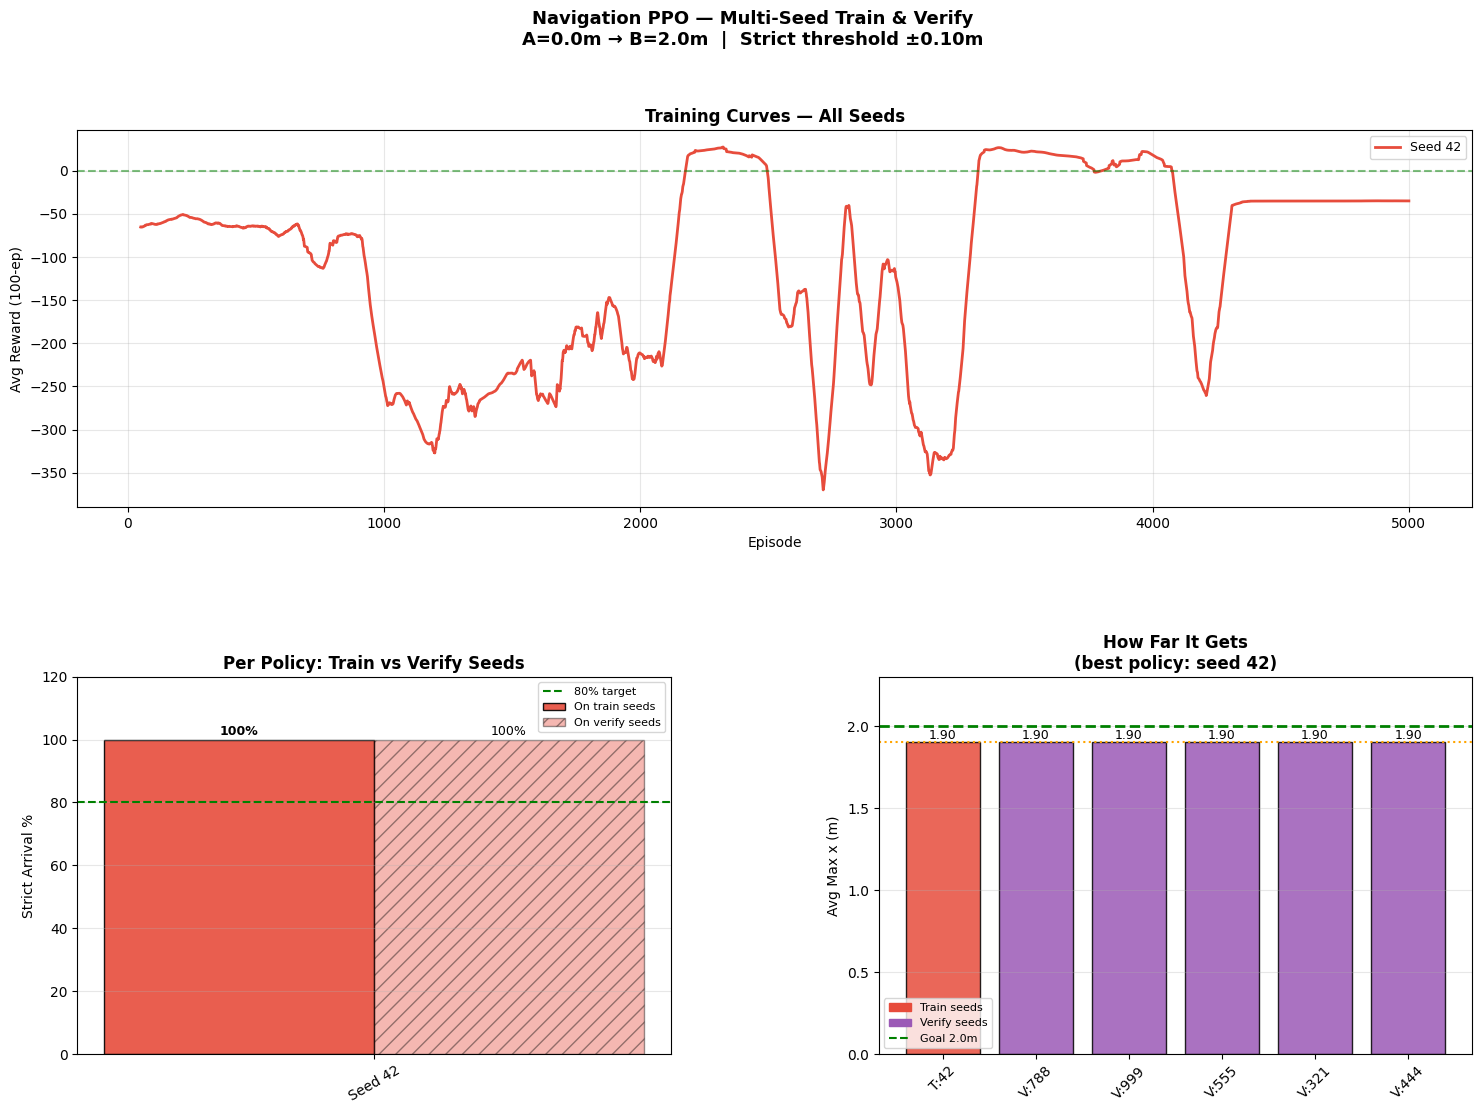

Saved: nav_multi_seed.png


In [28]:
# run everything
(all_nav_nets, all_nav_rewards,
 all_nav_losses, cross_results) = \
    run_nav_multi_seed(
        train_seeds  = [42], #TRAIN_SEEDS [42, 123, 777, 256, 512]
        verify_seeds = VERIFY_SEEDS,
        x_goal       = 2.0,
        tag          = "nav_v7_11",
        max_episodes = 5000)

/var/folders/s_/rqrsj_qd1kj4qh2qrgpmv_800000gn/T/ipykernel_74808/2609694973.py:244: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("nav_analysis.png",
/Users/kchong99/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


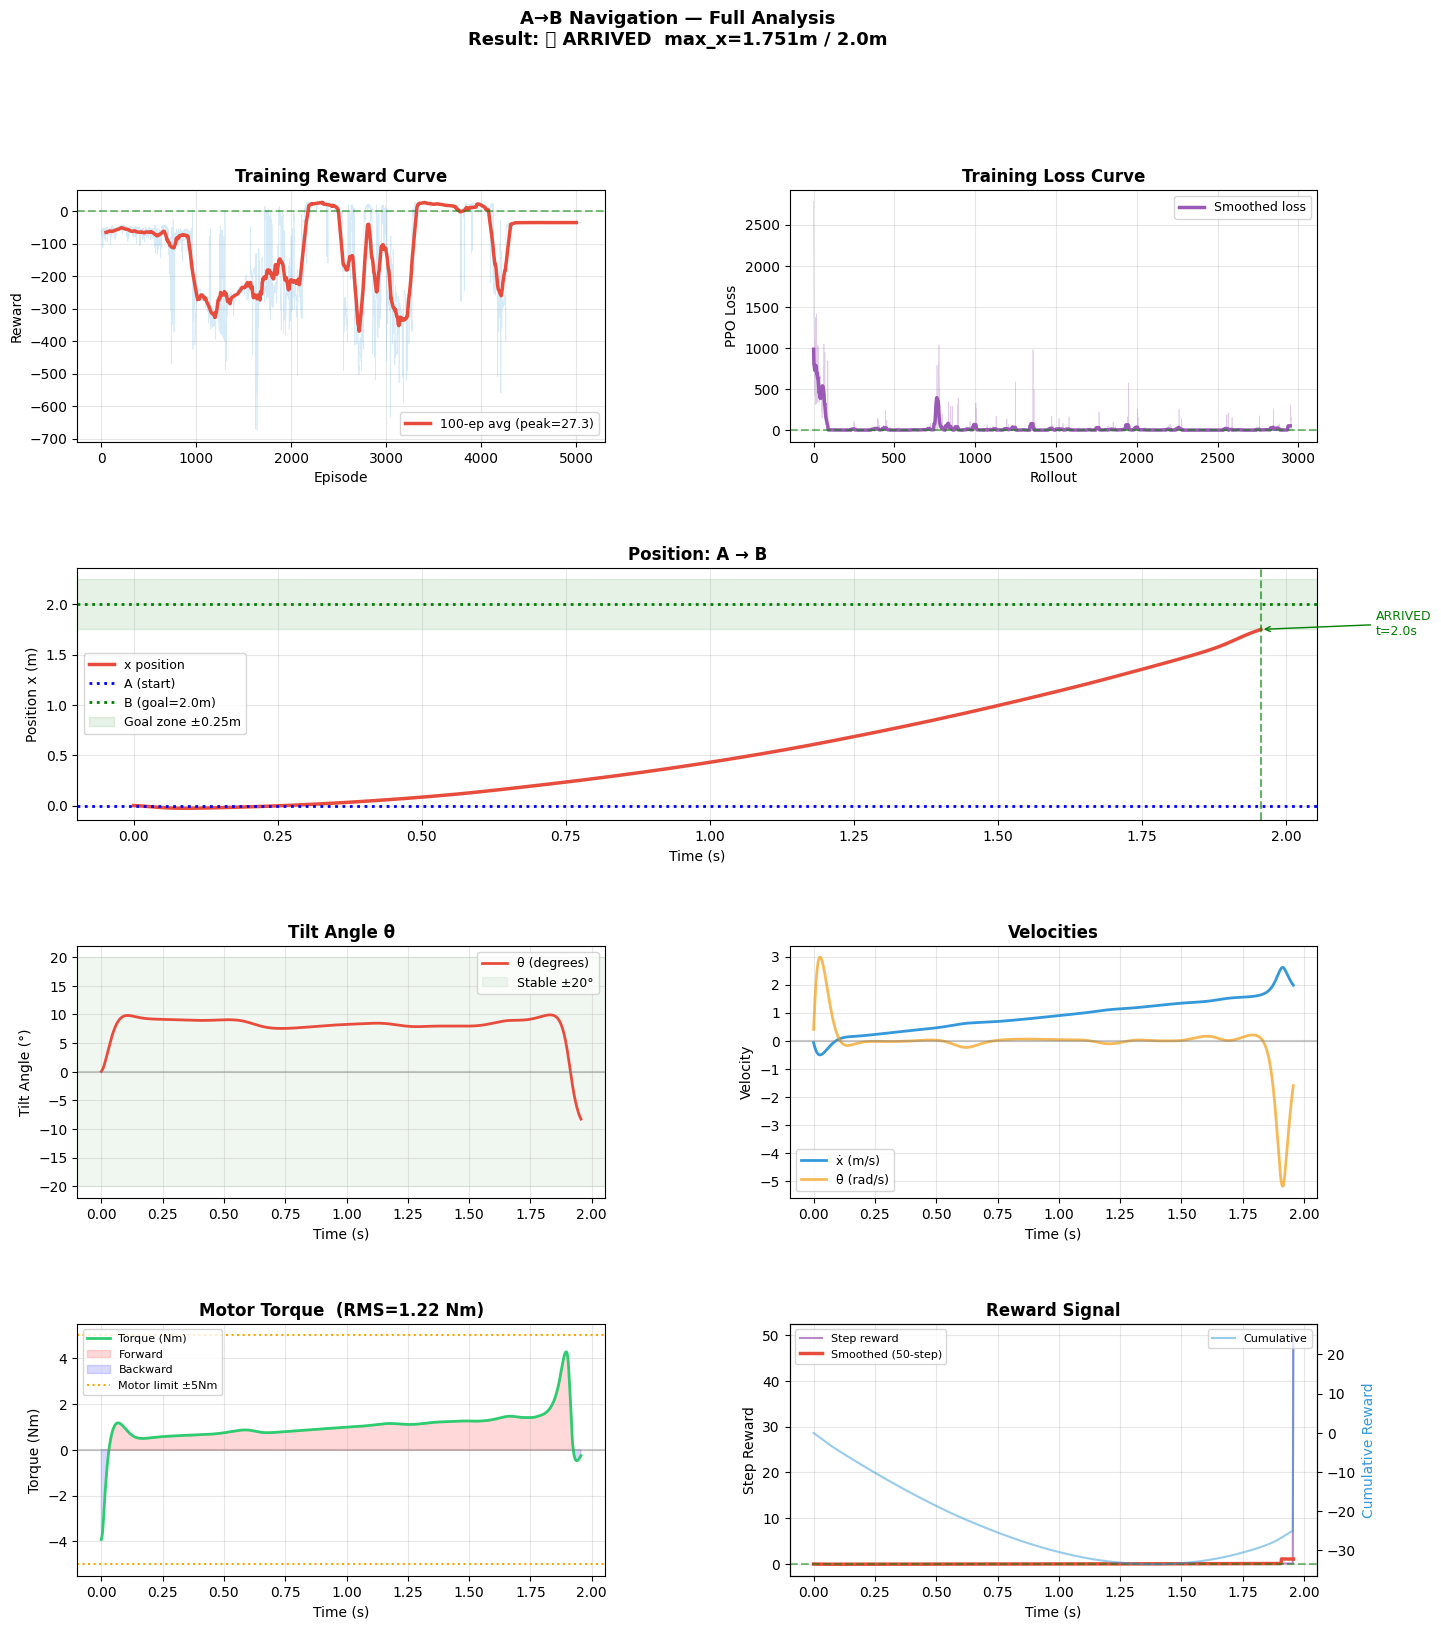

Saved: nav_analysis.png

  Episode Summary
  Duration   : 2.0s  (979 steps)
  Max x      : 1.751m  / 2.0m
  Final x    : 1.751m
  Avg tilt   : 8.2°
  Max tilt   : 9.9°
  Torque RMS : 1.219 Nm
  Saturated  : 0 / 979 steps (0%)
  Total reward: 24.9

  Tuning suggestions:
  → Getting close but slow — increase MAX_EP_STEPS or add near-goal bonus


In [29]:
# # ── run it ────────────────────────────────────────────────
# record_all_seeds(
#     all_nav_nets[42],          # ← index the dict, not pass the whole thing
#     train_seeds  = [42],
#     verify_seeds = VERIFY_SEEDS,
#     x_goal       = 2.0
# )

# ── analysis plot ─────────────────────────────────────────
plot_training_analysis(
    all_nav_rewards[42],       # ← reward list for seed 42
    all_nav_losses[42],        # ← loss list for seed 42
    all_nav_nets[42],
    x_goal=2.0
)